## Notebook setup

In [ ]:
!pip install -U gdown
!pip install git+https://github.com/Watts-Lab/nomad.git

In [ ]:
# Download data for tutorial
import gdown
from pathlib import Path

data_url = "https://drive.google.com/drive/folders/1Y88OdsiyidywcXTcSXlsXi86d85Uv9q8?usp=drive_link"
input_path = Path("data")

input_path.mkdir(parents=True, exist_ok=True)
gdown.download_folder(
    url=data_url,
    output=str(input_path),
    quiet=False,
    use_cookies=False,
)

## Packages and helpers

In [1]:
from pathlib import Path
import geopandas as gpd
import contextily as cx
import matplotlib.pyplot as plt
plt.rcParams['font.family'] = 'monospace'
import pandas as pd
import nomad.io.base as loader
from nomad import filters
import nomad.data as nomad_data
from nomad.stop_detection.viz import plot_time_barcode, plot_pings, plot_stops_barcode

# Choroplet helper for later
def choropleth_folium(gdf, key_col, val_col, m = None, fill_cmap = 'YlGnBu'):
    gdf = gdf.to_crs(4326)
    if m == None:
      m = folium.Map(width = 850, height = 500, location=[gdf.geometry.centroid.y.mean(), gdf.geometry.centroid.x.mean()], zoom_start=10,tiles="Cartodb Positron")
    folium.Choropleth(
        geo_data=gdf.to_json(),
        data=gdf,
        columns=[key_col, val_col],
        key_on=f'feature.properties.{key_col}',
        fill_color=fill_cmap,
        fill_opacity=0.7,
        line_opacity=0.2,
        legend_name=val_col
    ).add_to(m)
    return m

## Examples of Mobility Data and Visualizations

In part 1 of this notebook we will visualize different types of human mobility data. 

### Raw trajectory data

Raw trajectory data corresponds to sequences of time-stamped coordinates (or position-fixes) for a panel of different users. Lets explore this by loading some synthetic mobility data. We can use pandas to load this csv data, or use nomad's helpers that assist with formatting and column names. 

In [2]:
# Load data
data_dir = Path(nomad_data.__file__).parent
# Single csv
print("\nColumns for single csv sample:")
print(loader.table_columns(data_dir / "single_csv/sample2.csv", format="csv"))
# Partitioned data
print("\nColumns for partitioned csv sample:")
print(loader.table_columns(data_dir / "partitioned_csv/", format="csv"))
# Contents:
print("\nPartitioned Dataset Structure:")
print("partitioned_csv/")
for folder in sorted((data_dir / "partitioned_csv").iterdir()):
    print(f"├── {folder.name}/")
    print(f"│   └── {next(folder.iterdir()).name}")


Columns for single csv sample:
Index(['uid', 'timestamp', 'latitude', 'longitude'], dtype='object')

Columns for partitioned csv sample:
Index(['user_id', 'dev_lat', 'dev_lon', 'local_datetime'], dtype='object')

Partitioned Dataset Structure:
partitioned_csv/
├── 2024-01-01/
│   └── part-0.csv
├── 2024-01-02/
│   └── part-0.csv
├── 2024-01-03/
│   └── part-0.csv
├── 2024-01-04/
│   └── part-0.csv
├── 2024-01-05/
│   └── part-0.csv
├── 2024-01-06/
│   └── part-0.csv
├── 2024-01-07/
│   └── part-0.csv
├── 2024-01-08/
│   └── part-0.csv
├── 2024-01-09/
│   └── part-0.csv
├── 2024-01-10/
│   └── part-0.csv
├── 2024-01-11/
│   └── part-0.csv
├── 2024-01-12/
│   └── part-0.csv
├── 2024-01-13/
│   └── part-0.csv
├── 2024-01-14/
│   └── part-0.csv
├── 2024-01-15/
│   └── part-0.csv


In [3]:
df =  pd.read_csv(data_dir / "single_csv/sample2.csv")
df.head(10)

,uid,timestamp,latitude,longitude
0,admiring_tereshkova,1704119616,36.668980,-38.317759
1,admiring_tereshkova,1704119658,36.668911,-38.317800
2,admiring_tereshkova,1704120310,36.669108,-38.317719
3,admiring_tereshkova,1704121048,36.669003,-38.317879
4,admiring_tereshkova,1704121154,36.668904,-38.317732
5,admiring_tereshkova,1704122012,36.668844,-38.317657
6,admiring_tereshkova,1704122529,36.668796,-38.317650
7,admiring_tereshkova,1704122740,36.668861,-38.317816
8,admiring_tereshkova,1704133924,36.668955,-38.317783
9,admiring_tereshkova,1704136283,36.668872,-38.317695


In [4]:
# Nomad's helper can simplify reading from partitioned data and handling datetime formats
df = loader.from_file(
    data_dir / "partitioned_csv/",
    format="csv",
    user_id="user_id",             
    latitude="dev_lat",
    longitude="dev_lon",
    datetime="local_datetime")

user = df['user_id'].unique()[0]
date = pd.to_datetime("2024-01-08").date()

user_df = df[(df["user_id"] == user) & (df.local_datetime.dt.date == date)]
user_df.head(20)

,user_id,dev_lat,dev_lon,local_datetime,tz_offset
251,admiring_tereshkova,36.668923,-38.317712,2024-01-08 08:05:57,-14400
252,admiring_tereshkova,36.668866,-38.317870,2024-01-08 09:39:32,-14400
253,admiring_tereshkova,36.668837,-38.317990,2024-01-08 09:56:59,-14400
254,admiring_tereshkova,36.668786,-38.317719,2024-01-08 09:57:00,-14400
255,admiring_tereshkova,36.668972,-38.317659,2024-01-08 10:20:42,-14400
256,admiring_tereshkova,36.668882,-38.317627,2024-01-08 10:27:34,-14400
257,admiring_tereshkova,36.669004,-38.317922,2024-01-08 10:43:59,-14400
258,admiring_tereshkova,36.668979,-38.317580,2024-01-08 11:58:47,-14400
259,admiring_tereshkova,36.670569,-38.319336,2024-01-08 12:35:53,-14400
260,admiring_tereshkova,36.668456,-38.317123,2024-01-08 12:57:04,-14400


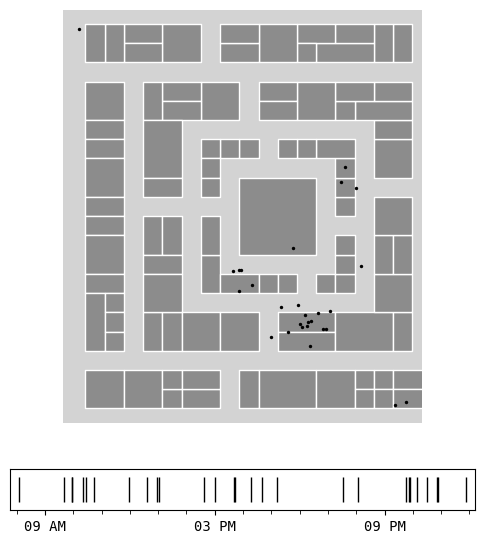

In [5]:
city = gpd.read_file(data_dir / "garden-city-buildings.geojson")
fig, (ax_map, ax_barcode) = plt.subplots(2, 1, figsize=(6,6.5),
                                         gridspec_kw={'height_ratios':[10,1]})
plot_pings(user_df,
           ax=ax_map,
           s=6,
           color='black',
           base_geometry=city,
           base_geom_color='#8c8c8c',
           base_geom_background='#d3d3d3',
           latitude="dev_lat",
           longitude="dev_lon")

plot_time_barcode(user_df['local_datetime'], ax=ax_barcode, set_xlim=True)
plt.show()

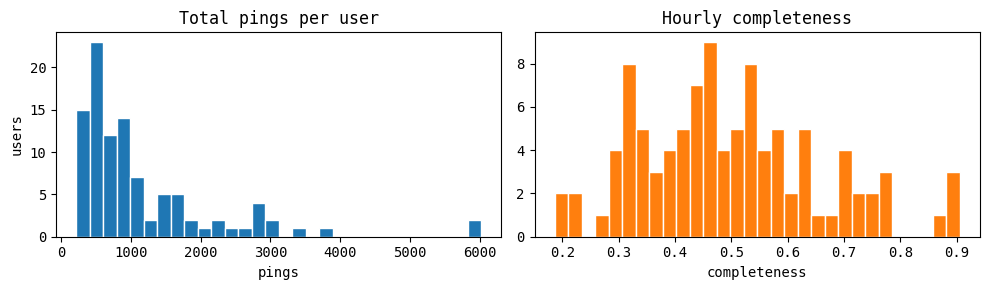

In [6]:
# How complete is this data?
total_pings = df.groupby(df['user_id']).size()
q_hourly = filters.completeness(df, periods=1, freq='h', datetime='local_datetime')


fig, (ax1, ax2) = plt.subplots(figsize=(10,3), ncols=2)

ax1.hist(total_pings, bins=30, color='tab:blue', edgecolor='white')
ax1.set_title('Total pings per user')
ax1.set_xlabel('pings')
ax1.set_ylabel('users')

ax2.hist(q_hourly, bins=30, color='tab:orange', edgecolor='white')
ax2.set_title('Hourly completeness')
ax2.set_xlabel('completeness')

plt.tight_layout()

### Stops data

Stop tables can be obtained from raw data via stop-detection algorithms, they represent approximate locations where individuals spent a certain amount of time. We can visualize some stop data from a sample coming from [1].

[1] Zhong, Chen, et al. "Anonymised human location data in England for urban mobility research." Scientific Data (2025).

In [7]:
df = loader.from_file(
    "data/london_10_users.csv",
    format="csv",
    user_id="userid",             
    y="o_lat",
    x="o_lon",
    start_datetime="start_time",
    end_datetime="end_time")


C:\Users\franc\Desktop\Code Development\nomad\nomad\io\base.py:626: UserWarning: The 'start_time' column has timezone-naive records consider localizing or using unix timestamps.
  warnings.warn(f"The '{col}' column has timezone-naive records consider localizing or using unix timestamps.")
C:\Users\franc\Desktop\Code Development\nomad\nomad\io\base.py:626: UserWarning: The 'end_time' column has timezone-naive records consider localizing or using unix timestamps.
  warnings.warn(f"The '{col}' column has timezone-naive records consider localizing or using unix timestamps.")


This data seem to already have a geometry column with WKT strings, which can simplify the plotting. It also has misleading column names, since the latitude and longitude columns are actually projected coordinates in transverse Mercator projection. The projection is EPSG:27700

In [8]:
user_df

,user_id,dev_lat,dev_lon,local_datetime,tz_offset
251,admiring_tereshkova,36.668923,-38.317712,2024-01-08 08:05:57,-14400
252,admiring_tereshkova,36.668866,-38.317870,2024-01-08 09:39:32,-14400
253,admiring_tereshkova,36.668837,-38.317990,2024-01-08 09:56:59,-14400
254,admiring_tereshkova,36.668786,-38.317719,2024-01-08 09:57:00,-14400
255,admiring_tereshkova,36.668972,-38.317659,2024-01-08 10:20:42,-14400
256,admiring_tereshkova,36.668882,-38.317627,2024-01-08 10:27:34,-14400
257,admiring_tereshkova,36.669004,-38.317922,2024-01-08 10:43:59,-14400
258,admiring_tereshkova,36.668979,-38.317580,2024-01-08 11:58:47,-14400
259,admiring_tereshkova,36.670569,-38.319336,2024-01-08 12:35:53,-14400
260,admiring_tereshkova,36.668456,-38.317123,2024-01-08 12:57:04,-14400


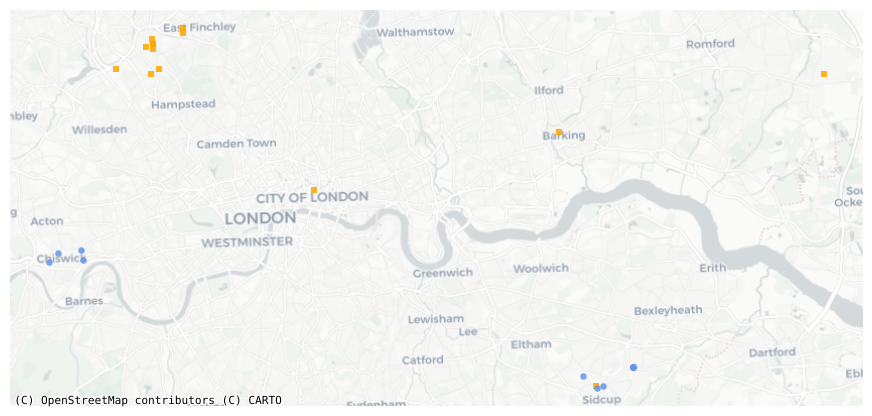

In [9]:
user = df['userid'].unique()[0]
user_2 = df['userid'].unique()[1]
user_df = df[(df["userid"] == user)]
user_df_2 = df[(df["userid"] == user_2)]

fig, ax = plt.subplots(figsize=(11, 11))

plot_pings(
    user_df,
    ax=ax,
    color="orange",
    marker="s",
    s=22,
    alpha=0.85,
    y="o_lat",
    x="o_lon",
    data_crs="EPSG:27700"
)
plot_pings(
    user_df_2,
    ax=ax,
    color="cornflowerblue",
    s=22,
    alpha=0.85,
    y="o_lat",
    x="o_lon",
    data_crs="EPSG:27700"
)

cx.add_basemap(ax, crs="EPSG:27700", source=cx.providers.CartoDB.Positron)

plt.show()

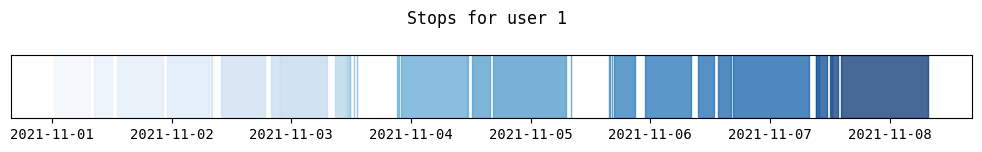

In [10]:
fig, ax_barcode = plt.subplots(figsize=(10,1.5))

plot_stops_barcode(user_df, ax=ax_barcode, cmap='Blues', set_xlim=False, timestamp='start_time')
fig.suptitle("Stops for user 1")
plt.tight_layout()
plt.show()

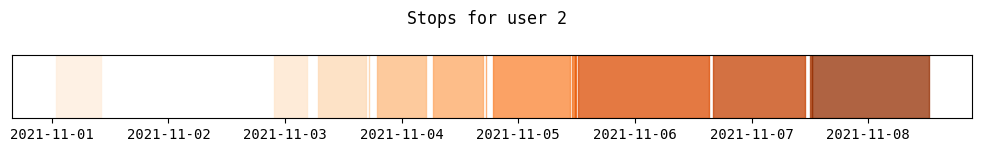

In [11]:
fig, ax_barcode = plt.subplots(figsize=(10,1.5))

plot_stops_barcode(user_df_2, ax=ax_barcode, cmap='Oranges', set_xlim=False, timestamp='start_time')
fig.suptitle("Stops for user 2")
plt.tight_layout()
plt.show()

These stops seem to have very high coverage. Let's try to use the semantic information of "Activity Type" to learn more about each stop and the differences between users. 

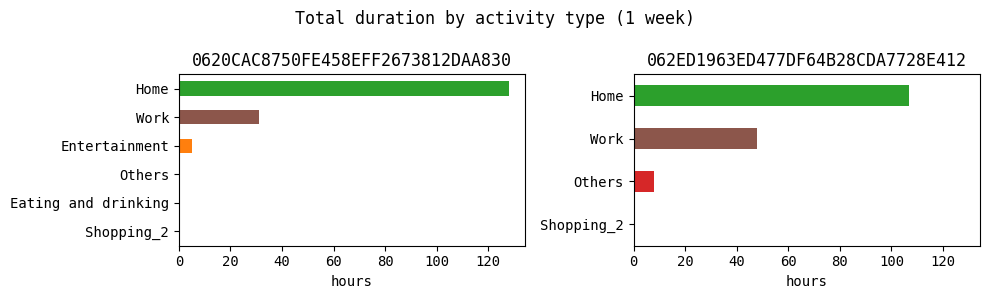

In [12]:
users = df["userid"].drop_duplicates().sort_values().iloc[[8, 9]]
stops = df[df["userid"].isin(users) & (df["duration"] > 5)].copy()
activity_colors = dict(zip(stops["activity_type"].sort_values().unique(), plt.get_cmap("tab10").colors))
stops["activity_color"] = stops["activity_type"].map(activity_colors)

duration = stops.groupby(["userid", "activity_type"])["duration"].sum().div(60)
fig, axes = plt.subplots(1, 2, figsize=(10, 3), sharex=True)

for ax, user in zip(axes, users):
    user_duration = duration.loc[user].sort_values()
    user_duration.plot.barh(ax=ax, color=user_duration.index.map(activity_colors))
    ax.set_title(user)
    ax.set_xlabel("hours")
    ax.set_ylabel("")

fig.suptitle("Total duration by activity type (1 week)")
plt.tight_layout()


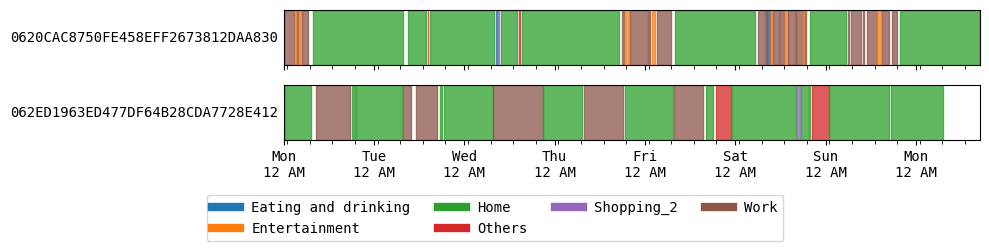

In [13]:
fig, axes = plt.subplots(2, 1, figsize=(10, 2.5), sharex=True)
xlim = stops["start_time"].min(), stops["end_time"].max()

for ax, user in zip(axes, users):
    plot_stops_barcode(
        stops[stops["userid"] == user],
        ax=ax,
        cmap=None,
        stop_color="activity_color",
        set_xlim=True,
        timestamp="start_time"
    )
    ax.set_xlim(xlim)
    ax.set_ylabel(user, rotation=0, ha="right", va="center")

fig.legend(
    [plt.Line2D([0], [0], color=color, lw=6) for color in activity_colors.values()],
    activity_colors.keys(),
    loc="lower center",
    ncol=4,
)
plt.tight_layout(rect=[0, 0.2, 1, 1])
plt.show()


## Home Tables and Normalization

A sufficiently long table of stops can be used to identify a device's "home" location, typically defined using administrative boundaries or a tessellation. We will load a sample of aggregated home counts that was made publicly available by Safegraph in early 2020. [2]

[2] https://docs.safegraph.com/docs/social-distancing-metrics

In [14]:
tracts = gpd.read_file("data/Census_Tracts_2010.geojson")

census_pop = pd.read_csv("data/census_pop.csv", dtype={"GEOID10": str})

sg_homes = pd.read_csv("data/sg_home_counts.csv", dtype={"GEOID10": str})
sg_homes

,GEOID10,2020-01-01,2020-01-02,2020-01-03,2020-01-04,2020-01-05,2020-01-06,2020-01-07,2020-01-08,2020-01-09,...,2020-07-22,2020-07-23,2020-07-24,2020-07-25,2020-07-26,2020-07-27,2020-07-28,2020-07-29,2020-07-30,2020-07-31
0,42101009400,290.0,283.0,269,290.0,270.0,283.0,272.0,290.0,281.0,...,172,177,167,169,159,157.0,188,188,189,171
1,42101009500,173.0,177.0,183,184.0,190.0,186.0,184.0,204.0,182.0,...,139,146,153,135,137,154.0,142,141,152,143
2,42101009600,207.0,221.0,223,208.0,218.0,195.0,197.0,220.0,206.0,...,202,196,194,208,201,200.0,193,192,190,186
3,42101013800,61.0,72.0,66,62.0,71.0,68.0,66.0,68.0,76.0,...,63,59,61,51,54,62.0,54,61,53,48
4,42101013900,103.0,107.0,104,94.0,97.0,104.0,107.0,96.0,98.0,...,106,103,105,114,114,110.0,120,125,116,113
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
371,42101037200,305.0,294.0,302,287.0,301.0,281.0,265.0,289.0,277.0,...,216,218,210,217,241,237.0,232,227,225,216
372,42101038300,172.0,178.0,170,164.0,170.0,168.0,158.0,161.0,166.0,...,156,131,155,144,148,132.0,143,147,132,131
373,42101039000,386.0,364.0,359,356.0,340.0,333.0,353.0,346.0,341.0,...,296,290,317,299,275,313.0,297,317,310,307
374,42101037800,145.0,145.0,126,134.0,129.0,139.0,141.0,125.0,134.0,...,105,117,116,112,94,110.0,119,128,116,119


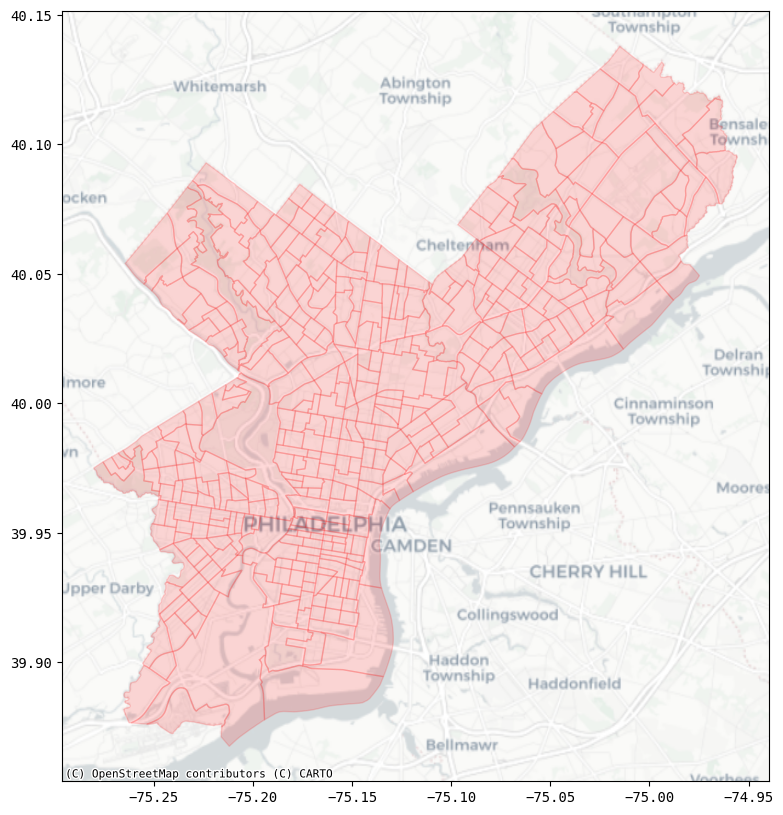

In [15]:
fig, ax = plt.subplots(figsize=(10, 10))
tracts.plot(ax=ax, alpha=0.15, facecolor="red", edgecolor="red")
cx.add_basemap(ax, crs=tracts.crs, source=cx.providers.CartoDB.Positron)
plt.show()

In [16]:
print("\nCensus tract geojson columns:")
print(tracts.columns)

print("\nWe can join on GEOID10:")
tracts.GEOID10


Census tract geojson columns:
Index(['OBJECTID', 'STATEFP10', 'COUNTYFP10', 'TRACTCE10', 'GEOID10', 'NAME10',
       'NAMELSAD10', 'MTFCC10', 'FUNCSTAT10', 'ALAND10', 'AWATER10',
       'INTPTLAT10', 'INTPTLON10', 'LOGRECNO', 'geometry'],
      dtype='object')

We can join on GEOID10:


0      42101009400
1      42101009500
2      42101009600
3      42101013800
4      42101013900
          ...     
379    42101037200
380    42101038300
381    42101039000
382    42101037800
383    42101037700
Name: GEOID10, Length: 384, dtype: object

In [17]:
tracts.set_index("GEOID10", inplace=True)
sg_homes.set_index("GEOID10", inplace=True)
census_pop.set_index("GEOID10", inplace=True)

Combining these three sources of information we can obtain an **inferred sampling rate** for each Census Tract in Philadelphia, which we can compute as `device_count / population`

In [18]:
df_jan_1 = sg_homes[["2020-01-01"]].join(census_pop)
df_jan_1["w"] = (df_jan_1["2020-01-01"]/df_jan_1.population).round(4)
df_jan_1

,2020-01-01,population,w
GEOID10,,,
42101009400,290.0,4123,0.0703
42101009500,173.0,3065,0.0564
42101009600,207.0,4311,0.0480
42101013800,61.0,2118,0.0288
42101013900,103.0,2960,0.0348
...,...,...,...
42101037200,305.0,4608,0.0662
42101038300,172.0,3744,0.0459
42101039000,386.0,9285,0.0416


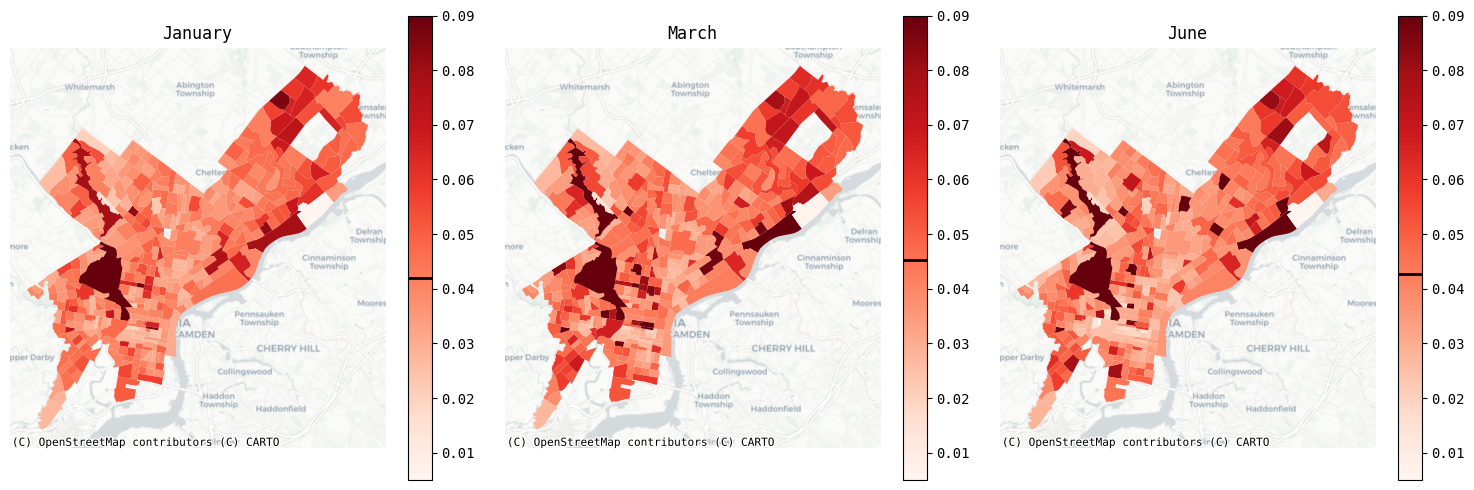

In [26]:
dates = pd.to_datetime(sg_homes.columns)
device_counts = pd.DataFrame({
    "jan": sg_homes.loc[:, dates.month == 1].mean(axis=1),
    "mar": sg_homes.loc[:, dates.month == 3].mean(axis=1),
    "jun": sg_homes.loc[:, dates.month == 6].mean(axis=1),
})

rates = device_counts.join(census_pop)
rates[["w_jan", "w_mar", "w_jun"]] = rates[["jan", "mar", "jun"]].div(rates["population"], axis=0)
tract_rates = tracts.join(rates[["w_jan", "w_mar", "w_jun"]])

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for ax, col, month, title in zip(axes, ["w_jan", "w_mar", "w_jun"], ["jan", "mar", "jun"], ["January", "March", "June"]):
    tract_rates.plot(column=col, ax=ax, cmap="Reds", vmin=0.005, vmax=0.09, legend=True)
    fig.axes[-1].axhline(rates[month].sum() / rates["population"].sum(), color="black", lw=2)
    cx.add_basemap(ax, crs=tracts.crs, source=cx.providers.CartoDB.Positron)
    ax.set_title(title)
    ax.axis("off")

plt.tight_layout()
